# Corporate Signal Intelligence  
## Anomaly Detection Modeling Notebook

> This notebook builds the first machine learning layer of the **Corporate Signal Intelligence** project, using engineered market, filing, and financial features to detect abnormal corporate and market behavior.

---

## Project Stage

The previous notebooks completed the following stages:

| Stage | Output |
|---|---|
| Data Collection | Raw market, SEC filing, and SEC financial facts datasets |
| Data Analysis & Cleansing | Cleaned market, filing, company, and financial datasets |
| Feature Engineering | Model-ready features from market behavior, filing activity, and financial fundamentals |

This notebook now focuses on training and evaluating anomaly detection models using the final feature dataset.

---

## Modeling Objective

The goal of this notebook is to identify unusual patterns across monitored public companies by combining:

```text
market behavior
filing activity
financial fundamentals
corporate reporting signals
```

The model will attempt to detect observations that differ significantly from normal historical behavior.

Potential anomaly types include:

```text
price movement anomaly
volume anomaly
volatility anomaly
filing activity anomaly
financial fundamentals anomaly
combined corporate signal anomaly
```

---

## Input Dataset

The main input for this notebook is:

```text
data/model_ready_dataset.csv
```

This dataset combines:

| Feature Layer | Description |
|---|---|
| Market Features | Returns, volatility, price changes, volume signals |
| Filing Features | 10-K, 10-Q, 8-K activity and filing recency |
| Financial Features | Revenue, margins, assets, cash, equity, growth indicators |

---

## Modeling Strategy

This project will start with unsupervised anomaly detection models, because the dataset does not contain manually labeled anomalies.

The first models to test are:

```text
Z-score baseline
Isolation Forest
Local Outlier Factor
One-Class SVM
```

The initial benchmark model will be **Isolation Forest**, because it is well-suited for tabular anomaly detection and works without labeled data.

---

## Missing Value Strategy

Some financial features still contain missing values due to differences in how companies report SEC XBRL concepts.

Missing values will be handled inside the modeling pipeline using imputation strategies such as:

```text
median imputation
complete-case comparison
feature exclusion when necessary
```

This avoids hardcoding imputation too early in the feature engineering stage.

---

## Expected Outputs

By the end of this notebook, the project should produce:

```text
trained anomaly detection model
anomaly scores
anomaly labels
model comparison results
anomaly-ranked dataset
saved model artifacts
```

The final output dataset will later be used by the FastAPI backend and dashboard layer.

---

## Final Pipeline Context

```text
Model-Ready Dataset
        ↓
Preprocessing Pipeline
        ↓
Anomaly Detection Models
        ↓
Anomaly Scores & Labels
        ↓
Groq Executive Briefings
        ↓
FastAPI + Dashboard
```

This notebook represents the first machine learning implementation of the Corporate Signal Intelligence platform.

In [1]:
# Installing required dependencies

%pip install \
    pandas \
    numpy \
    scipy \
    scikit-learn \
    matplotlib \
    seaborn \
    plotly \
    joblib \
    pyarrow

print("\n Dependencies installed successfully!")

Note: you may need to restart the kernel to use updated packages.

 Dependencies installed successfully!


In [2]:
# Importing Python libraries

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy import stats

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

from sklearn.decomposition import PCA

import joblib

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_DIR = Path("data")
MODELS_DIR = Path("models")

MODELS_DIR.mkdir(exist_ok=True)

print("Libraries loaded successfully.")
print("Data directory:", DATA_DIR.resolve())
print("Models directory:", MODELS_DIR.resolve())

Libraries loaded successfully.
Data directory: /home/a1rm4x/Documents/GitHub/corporate-signal-intelligence/data
Models directory: /home/a1rm4x/Documents/GitHub/corporate-signal-intelligence/models


In [3]:
# Checking the system

import sys

print("Python executable:", sys.executable)
print("Python version:", sys.version)

Python executable: /home/a1rm4x/Documents/GitHub/corporate-signal-intelligence/.venv/bin/python
Python version: 3.14.4 (main, Apr  8 2026, 17:48:49) [GCC 15.2.1 20260209]


In [4]:
# Loading the dataset

model_ready_df = pd.read_csv(DATA_DIR / "model_ready_dataset.csv")

model_ready_df["date"] = pd.to_datetime(model_ready_df["date"], errors="coerce")

if "reference_date" in model_ready_df.columns:
    model_ready_df["reference_date"] = pd.to_datetime(
        model_ready_df["reference_date"],
        errors="coerce",
    )

print("model_ready_df shape:", model_ready_df.shape)

model_ready_df.head()

model_ready_df shape: (27730, 58)


,ticker,date,open,high,low,close,volume,source,collected_at,daily_return,log_return,price_change_7d,price_change_30d,price_change_90d,volatility_7d,volatility_30d,volatility_90d,avg_volume_30d,std_volume_30d,volume_change_30d,volume_zscore_30d,avg_return_30d,std_return_30d,return_zscore_30d,daily_range,open_gap,filing_count,form_10k_count,form_10q_count,form_8k_count,filing_count_30d,filing_count_90d,form_8k_count_30d,form_10q_count_180d,form_10k_count_365d,days_since_last_filing,days_since_last_8k,reference_date,fiscal_year,fiscal_period,assets,cash_and_equivalents,net_income,operating_income,rd_expense,revenue,stockholders_equity,operating_margin,net_margin,cash_to_assets,equity_to_assets,rd_to_revenue,revenue_growth_qoq,revenue_growth_yoy,net_income_growth_qoq,net_income_growth_yoy,assets_growth_qoq,has_missing_financial_data
0,AAPL,2015-05-13,28.1670,28.4023,28.1062,28.1376,"155,379,331.0000",stooq,2026-05-21 19:51:02.287737+00:00,0.0012,0.0012,-0.0167,0.0170,0.1620,0.0130,0.0132,0.0161,"217,353,230.9000","94,016,158.6912",-0.2851,-0.6592,0.0006,0.0132,0.0411,0.0105,0.0022,1,0,0,1,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,2015-03-28,"2,016.0000",Q2,"261,194,000,000.0000","14,489,000,000.0000","31,593,000,000.0000","42,524,000,000.0000","3,813,000,000.0000",NaN,"129,006,000,000.0000",NaN,NaN,0.0555,0.4939,NaN,NaN,NaN,0.7528,0.7528,-0.0027,1
1,AAPL,2015-05-14,28.4505,28.7970,28.3955,28.7970,"202,444,982.0000",stooq,2026-05-21 19:51:02.287737+00:00,0.0234,0.0232,0.0293,0.0423,0.2237,0.0128,0.0138,0.0159,"218,011,922.3333","93,833,933.5375",-0.0714,-0.1659,0.0015,0.0138,1.5892,0.0139,0.0111,0,0,0,0,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,2015-03-28,"2,016.0000",Q2,"261,194,000,000.0000","14,489,000,000.0000","31,593,000,000.0000","42,524,000,000.0000","3,813,000,000.0000",NaN,"129,006,000,000.0000",NaN,NaN,0.0555,0.4939,NaN,NaN,NaN,0.7528,0.7528,-0.0027,1
2,AAPL,2015-05-15,28.8244,28.9237,28.6280,28.7557,"171,052,227.0000",stooq,2026-05-21 19:51:02.287737+00:00,-0.0014,-0.0014,0.0345,0.0320,0.2218,0.0122,0.0138,0.0159,"218,883,610.9333","93,250,996.0012",-0.2185,-0.5129,0.0011,0.0138,-0.1871,0.0103,0.0010,0,0,0,0,1.0000,1.0000,1.0000,0.0000,0.0000,2.0000,2.0000,2015-03-28,"2,016.0000",Q2,"261,194,000,000.0000","14,489,000,000.0000","31,593,000,000.0000","42,524,000,000.0000","3,813,000,000.0000",NaN,"129,006,000,000.0000",NaN,NaN,0.0555,0.4939,NaN,NaN,NaN,0.7528,0.7528,-0.0027,1
3,AAPL,2015-05-18,28.6644,29.1845,28.6596,29.0639,"227,617,764.0000",stooq,2026-05-21 19:51:02.287737+00:00,0.0107,0.0107,0.0390,0.0265,0.2176,0.0124,0.0136,0.0159,"220,895,204.6667","92,748,755.8727",0.0304,0.0725,0.0010,0.0136,0.7179,0.0181,-0.0032,0,0,0,0,1.0000,1.0000,1.0000,0.0000,0.0000,5.0000,5.0000,2015-03-28,"2,016.0000",Q2,"261,194,000,000.0000","14,489,000,000.0000","31,593,000,000.0000","42,524,000,000.0000","3,813,000,000.0000",NaN,"129,006,000,000.0000",NaN,NaN,0.0555,0.4939,NaN,NaN,NaN,0.7528,0.7528,-0.0027,1
4,AAPL,2015-05-19,29.1776,29.2201,28.9530,29.0373,"199,891,497.0000",stooq,2026-05-21 19:51:02.287737+00:00,-0.0009,-0.0009,0.0190,0.0364,0.1716,0.0111,0.0134,0.0154,"222,312,705.3667","92,066,804.2472",-0.1009,-0.2435,0.0013,0.0134,-0.1633,0.0092,0.0039,0,0,0,0,1.0000,1.0000,1.0000,0.0000,0.0000,6.0000,6.0000,2015-03-28,"2,016.0000",Q2,"261,194,000,000.0000","14,489,000,000.0000","31,593,000,000.0000","42,524,000,000.0000","3,813,000,000.0000",NaN,"129,006,000,000.0000",NaN,NaN,0.0555,0.4939,NaN,NaN,NaN,0.7528,0.7528,-0.0027,1


In [5]:
# Checking the missing values

missing_values = model_ready_df.isna().sum()
missing_pct = model_ready_df.isna().mean()

missing_summary = pd.DataFrame({
    "column": missing_values.index,
    "missing_values": missing_values.values,
    "missing_pct": missing_pct.values,
}).sort_values("missing_pct", ascending=False).reset_index(drop=True)

missing_summary[missing_summary["missing_values"] > 0]

,column,missing_values,missing_pct
0,rd_to_revenue,4009,0.1446
1,rd_expense,2773,0.1000
2,revenue_growth_yoy,2030,0.0732
3,revenue,1711,0.0617
4,operating_margin,1711,0.0617
5,revenue_growth_qoq,1711,0.0617
6,net_margin,1711,0.0617


In [6]:
# What if we dropped na

model_ready_complete_cases_df = model_ready_df.dropna().copy()

print("Original shape:", model_ready_df.shape)
print("Complete-case shape:", model_ready_complete_cases_df.shape)

rows_removed = len(model_ready_df) - len(model_ready_complete_cases_df)
removed_pct = rows_removed / len(model_ready_df)

print(f"Rows removed: {rows_removed:,}")
print(f"Removed percentage: {removed_pct:.2%}")

Original shape: (27730, 58)
Complete-case shape: (23402, 58)
Rows removed: 4,328
Removed percentage: 15.61%


In [7]:
# Checking which tickers would be most affected bby dropping na

dropna_impact_by_ticker = (
    model_ready_df.groupby("ticker")
    .size()
    .reset_index(name="original_rows")
    .merge(
        model_ready_complete_cases_df.groupby("ticker")
        .size()
        .reset_index(name="complete_case_rows"),
        on="ticker",
        how="left",
    )
)

dropna_impact_by_ticker["complete_case_rows"] = (
    dropna_impact_by_ticker["complete_case_rows"]
    .fillna(0)
    .astype(int)
)

dropna_impact_by_ticker["rows_removed"] = (
    dropna_impact_by_ticker["original_rows"]
    - dropna_impact_by_ticker["complete_case_rows"]
)

dropna_impact_by_ticker["removed_pct"] = (
    dropna_impact_by_ticker["rows_removed"]
    / dropna_impact_by_ticker["original_rows"]
)

dropna_impact_by_ticker.sort_values("removed_pct", ascending=False)

,ticker,original_rows,complete_case_rows,rows_removed,removed_pct
2,AMZN,2773,0,2773,1.0000
4,INTC,2773,2171,602,0.2171
1,AMD,2773,2234,539,0.1944
0,AAPL,2773,2359,414,0.1493
3,GOOGL,2773,2773,0,0.0000
5,META,2773,2773,0,0.0000
6,MSFT,2773,2773,0,0.0000
7,NVDA,2773,2773,0,0.0000
8,ORCL,2773,2773,0,0.0000
9,TSLA,2773,2773,0,0.0000


In [8]:
# Creating the list fo features for the model

identifier_columns = [
    "ticker",
    "date",
    "source",
    "collected_at",
    "reference_date",
    "fiscal_year",
    "fiscal_period",
]

target_or_helper_columns = [
    "has_missing_financial_data",
]

feature_columns = [
    col for col in model_ready_df.columns
    if col not in identifier_columns + target_or_helper_columns
]

print("Number of feature columns:", len(feature_columns))
print(feature_columns)

Number of feature columns: 50
['open', 'high', 'low', 'close', 'volume', 'daily_return', 'log_return', 'price_change_7d', 'price_change_30d', 'price_change_90d', 'volatility_7d', 'volatility_30d', 'volatility_90d', 'avg_volume_30d', 'std_volume_30d', 'volume_change_30d', 'volume_zscore_30d', 'avg_return_30d', 'std_return_30d', 'return_zscore_30d', 'daily_range', 'open_gap', 'filing_count', 'form_10k_count', 'form_10q_count', 'form_8k_count', 'filing_count_30d', 'filing_count_90d', 'form_8k_count_30d', 'form_10q_count_180d', 'form_10k_count_365d', 'days_since_last_filing', 'days_since_last_8k', 'assets', 'cash_and_equivalents', 'net_income', 'operating_income', 'rd_expense', 'revenue', 'stockholders_equity', 'operating_margin', 'net_margin', 'cash_to_assets', 'equity_to_assets', 'rd_to_revenue', 'revenue_growth_qoq', 'revenue_growth_yoy', 'net_income_growth_qoq', 'net_income_growth_yoy', 'assets_growth_qoq']


In [9]:
# Creatin the X variable

X = model_ready_df[feature_columns].copy()

print("X shape:", X.shape)
print("Missing values:", X.isna().sum().sum())

X shape: (27730, 50)
Missing values: 15656


In [10]:
# Creating the initial pipeline

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest

anomaly_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        ("model", IsolationForest(
            n_estimators=300,
            contamination=0.03,
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

In [11]:
# Fitting the pipeline

anomaly_pipeline.fit(X)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [12]:
# Scores

model_ready_df["anomaly_label"] = anomaly_pipeline.predict(X)
model_ready_df["is_anomaly"] = (model_ready_df["anomaly_label"] == -1).astype(int)

model_ready_df["anomaly_score"] = anomaly_pipeline.named_steps["model"].decision_function(
    anomaly_pipeline.named_steps["scaler"].transform(
        anomaly_pipeline.named_steps["imputer"].transform(X)
    )
)

model_ready_df[["ticker", "date", "anomaly_score", "is_anomaly"]].head()

,ticker,date,anomaly_score,is_anomaly
0,AAPL,2015-05-13,0.0630,0
1,AAPL,2015-05-14,0.1103,0
2,AAPL,2015-05-15,0.1195,0
3,AAPL,2015-05-18,0.1179,0
4,AAPL,2015-05-19,0.1168,0


In [13]:
# Main summary

# General anomaly summary
anomaly_summary = model_ready_df.groupby("ticker").agg(
    rows=("date", "count"),
    anomalies=("is_anomaly", "sum"),
    anomaly_rate=("is_anomaly", "mean"),
    min_score=("anomaly_score", "min"),
    avg_score=("anomaly_score", "mean"),
    max_score=("anomaly_score", "max"),
).sort_values("anomaly_rate", ascending=False)

anomaly_summary

,rows,anomalies,anomaly_rate,min_score,avg_score,max_score
ticker,,,,,,
TSLA,2773,207,0.0746,-0.0949,0.0646,0.1306
NVDA,2773,183,0.0660,-0.0933,0.0600,0.1173
META,2773,121,0.0436,-0.1417,0.0804,0.1370
GOOGL,2773,98,0.0353,-0.0996,0.1018,0.1455
INTC,2773,56,0.0202,-0.1298,0.1060,0.1482
AMD,2773,51,0.0184,-0.0952,0.0834,0.1356
AMZN,2773,40,0.0144,-0.0847,0.0918,0.1382
MSFT,2773,36,0.0130,-0.0646,0.0906,0.1500
AAPL,2773,22,0.0079,-0.0429,0.0881,0.1393


In [14]:
# Checking the most anomalous events

top_anomalies = model_ready_df[
    model_ready_df["is_anomaly"] == 1
].sort_values("anomaly_score", ascending=True)

top_anomalies[
    [
        "ticker",
        "date",
        "anomaly_score",
        "daily_return",
        "volume_zscore_30d",
        "return_zscore_30d",
        "volatility_30d",
        "filing_count_30d",
        "form_8k_count_30d",
        "revenue_growth_qoq",
        "net_margin",
        "operating_margin",
    ]
].head(30)

,ticker,date,anomaly_score,daily_return,volume_zscore_30d,return_zscore_30d,volatility_30d,filing_count_30d,form_8k_count_30d,revenue_growth_qoq,net_margin,operating_margin
16559,META,2026-01-29,-0.1417,0.1040,3.7746,3.9411,0.0252,4.0000,3.0000,0.4246,0.3008,0.4144
13845,INTC,2026-04-24,-0.1298,0.2360,3.8973,3.6633,0.0585,4.0000,3.0000,-0.7431,-0.2746,-0.2310
16498,META,2025-10-30,-0.1035,-0.1133,4.9981,-4.3870,0.0247,2.0000,1.0000,0.5704,0.2672,0.4149
24781,ORCL,2025-09-10,-0.1035,0.3595,5.0815,4.9926,0.0698,2.0000,1.0000,-0.7400,0.1961,0.2865
13695,INTC,2025-09-18,-0.1017,0.2277,3.8187,4.1694,0.0511,8.0000,8.0000,1.0152,-0.1465,-0.1362
11076,GOOGL,2026-04-30,-0.0996,0.0996,3.8239,3.4142,0.0269,4.0000,3.0000,-0.7272,0.5694,0.3612
3011,AMD,2016-04-22,-0.0952,0.5229,5.0834,4.8235,0.1036,0.0000,0.0000,NaN,NaN,NaN
26147,TSLA,2020-02-04,-0.0949,0.1372,3.5043,2.1496,0.0509,3.0000,3.0000,0.4295,-0.0351,-0.0028
13782,INTC,2026-01-23,-0.0946,-0.1703,2.9356,-3.3688,0.0520,4.0000,3.0000,0.3490,-0.0051,-0.0419
26178,TSLA,2020-03-19,-0.0942,0.1839,1.6477,2.5308,0.0785,3.0000,2.0000,0.4295,-0.0351,-0.0028


In [16]:
# Overall anomaly rate

overall_anomaly_rate = model_ready_df["is_anomaly"].mean()

print(f"Overall anomaly rate: {overall_anomaly_rate:.2%}")

Overall anomaly rate: 3.00%


In [17]:
# Classification of the anomaly using signals

def classify_anomaly_type(row):
    """
    Rule-based anomaly type classification based on engineered signals.
    """
    anomaly_types = []

    if abs(row.get("return_zscore_30d", 0)) >= 3:
        if row.get("daily_return", 0) > 0:
            anomaly_types.append("price_spike")
        else:
            anomaly_types.append("price_drop")

    if row.get("volume_zscore_30d", 0) >= 3:
        anomaly_types.append("volume_spike")

    if row.get("volatility_30d", 0) >= model_ready_df["volatility_30d"].quantile(0.95):
        anomaly_types.append("high_volatility")

    if row.get("filing_count_30d", 0) >= 3:
        anomaly_types.append("filing_activity")

    if pd.notna(row.get("revenue_growth_qoq")) and abs(row.get("revenue_growth_qoq")) >= 0.30:
        anomaly_types.append("revenue_shift")

    if pd.notna(row.get("net_margin")) and row.get("net_margin") < 0:
        anomaly_types.append("negative_margin")

    if not anomaly_types:
        anomaly_types.append("combined_signal")

    return ", ".join(anomaly_types)


model_ready_df["anomaly_type"] = model_ready_df.apply(
    classify_anomaly_type,
    axis=1,
)

model_ready_df.loc[
    model_ready_df["is_anomaly"] == 1,
    ["ticker", "date", "anomaly_score", "anomaly_type"]
].head(30)

,ticker,date,anomaly_score,anomaly_type
48,AAPL,2015-07-22,-0.0051,"volume_spike, filing_activity"
178,AAPL,2016-01-27,-0.0076,"volume_spike, filing_activity"
241,AAPL,2016-04-27,-0.0173,"price_drop, volume_spike, filing_activity"
304,AAPL,2016-07-27,-0.0173,"price_spike, volume_spike, filing_activity"
434,AAPL,2017-02-01,-0.0140,"price_spike, volume_spike, revenue_shift"
560,AAPL,2017-08-02,-0.0298,"price_spike, volume_spike"
588,AAPL,2017-09-12,-0.0134,"volume_spike, filing_activity"
626,AAPL,2017-11-03,-0.0254,"filing_activity, revenue_shift"
632,AAPL,2017-11-13,-0.0087,"filing_activity, revenue_shift"
811,AAPL,2018-08-01,-0.0212,"price_spike, volume_spike, revenue_shift"


In [18]:
# Checking the distribution of anomaly types

anomaly_type_summary = (
    model_ready_df[model_ready_df["is_anomaly"] == 1]
    ["anomaly_type"]
    .value_counts()
    .reset_index()
)

anomaly_type_summary.columns = ["anomaly_type", "count"]

anomaly_type_summary

,anomaly_type,count
0,"filing_activity, revenue_shift",140
1,revenue_shift,138
2,combined_signal,58
3,"high_volatility, filing_activity, revenue_shif...",54
4,high_volatility,48
5,"high_volatility, revenue_shift",45
6,"high_volatility, filing_activity",43
7,filing_activity,33
8,"volume_spike, revenue_shift",29
9,volume_spike,26


In [22]:
# Transformint the types of anomalies into a categorical variable

anomaly_types_exploded = (
    model_ready_df[model_ready_df["is_anomaly"] == 1]
    .assign(anomaly_type=model_ready_df["anomaly_type"].str.split(", "))
    .explode("anomaly_type")
)

anomaly_type_counts = (
    anomaly_types_exploded["anomaly_type"]
    .value_counts()
    .reset_index()
)

anomaly_type_counts.columns = ["anomaly_type", "count"]

anomaly_type_counts

,anomaly_type,count
0,revenue_shift,531
1,filing_activity,377
2,high_volatility,255
3,volume_spike,192
4,negative_margin,117
5,price_spike,73
6,combined_signal,58
7,price_drop,54


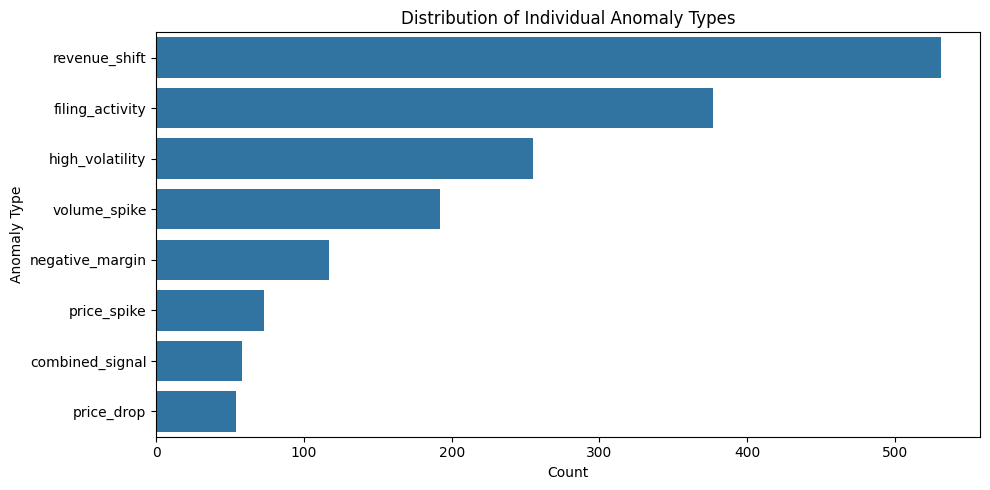

In [23]:
# Plotting a clean graph

plt.figure(figsize=(10, 5))

sns.barplot(
    data=anomaly_type_counts,
    x="count",
    y="anomaly_type"
)

plt.title("Distribution of Individual Anomaly Types")
plt.xlabel("Count")
plt.ylabel("Anomaly Type")
plt.tight_layout()
plt.show()

In [24]:
# Maintaining the original combination too

top_anomaly_combinations = (
    model_ready_df[model_ready_df["is_anomaly"] == 1]
    ["anomaly_type"]
    .value_counts()
    .reset_index()
)

top_anomaly_combinations.columns = ["anomaly_type_combination", "count"]

top_anomaly_combinations.head(15)

,anomaly_type_combination,count
0,"filing_activity, revenue_shift",140
1,revenue_shift,138
2,combined_signal,58
3,"high_volatility, filing_activity, revenue_shif...",54
4,high_volatility,48
5,"high_volatility, revenue_shift",45
6,"high_volatility, filing_activity",43
7,filing_activity,33
8,"volume_spike, revenue_shift",29
9,volume_spike,26


In [25]:
# Saving pipeline into a joblib file and the results into a csv

model_ready_df.to_csv("data/anomaly_detection_results.csv", index=False)

joblib.dump(
    anomaly_pipeline,
    "models/isolation_forest_anomaly_pipeline.joblib"
)

print("Anomaly results and model pipeline saved successfully.")

Anomaly results and model pipeline saved successfully.


In [26]:
# TOP anomalies table

top_anomalies_final = model_ready_df[
    model_ready_df["is_anomaly"] == 1
].sort_values("anomaly_score", ascending=True)

top_anomalies_final = top_anomalies_final[
    [
        "ticker",
        "date",
        "anomaly_score",
        "anomaly_type",
        "daily_return",
        "volume_zscore_30d",
        "return_zscore_30d",
        "volatility_30d",
        "filing_count_30d",
        "form_8k_count_30d",
        "revenue_growth_qoq",
        "net_margin",
        "operating_margin",
    ]
]

top_anomalies_final.head(30)

,ticker,date,anomaly_score,anomaly_type,daily_return,volume_zscore_30d,return_zscore_30d,volatility_30d,filing_count_30d,form_8k_count_30d,revenue_growth_qoq,net_margin,operating_margin
16559,META,2026-01-29,-0.1417,"price_spike, volume_spike, filing_activity, re...",0.1040,3.7746,3.9411,0.0252,4.0000,3.0000,0.4246,0.3008,0.4144
13845,INTC,2026-04-24,-0.1298,"price_spike, volume_spike, high_volatility, fi...",0.2360,3.8973,3.6633,0.0585,4.0000,3.0000,-0.7431,-0.2746,-0.2310
16498,META,2025-10-30,-0.1035,"price_drop, volume_spike, revenue_shift",-0.1133,4.9981,-4.3870,0.0247,2.0000,1.0000,0.5704,0.2672,0.4149
24781,ORCL,2025-09-10,-0.1035,"price_spike, volume_spike, high_volatility, re...",0.3595,5.0815,4.9926,0.0698,2.0000,1.0000,-0.7400,0.1961,0.2865
13695,INTC,2025-09-18,-0.1017,"price_spike, volume_spike, high_volatility, fi...",0.2277,3.8187,4.1694,0.0511,8.0000,8.0000,1.0152,-0.1465,-0.1362
11076,GOOGL,2026-04-30,-0.0996,"price_spike, volume_spike, filing_activity, re...",0.0996,3.8239,3.4142,0.0269,4.0000,3.0000,-0.7272,0.5694,0.3612
3011,AMD,2016-04-22,-0.0952,"price_spike, volume_spike, high_volatility",0.5229,5.0834,4.8235,0.1036,0.0000,0.0000,NaN,NaN,NaN
26147,TSLA,2020-02-04,-0.0949,"volume_spike, high_volatility, filing_activity...",0.1372,3.5043,2.1496,0.0509,3.0000,3.0000,0.4295,-0.0351,-0.0028
13782,INTC,2026-01-23,-0.0946,"price_drop, high_volatility, filing_activity, ...",-0.1703,2.9356,-3.3688,0.0520,4.0000,3.0000,0.3490,-0.0051,-0.0419
26178,TSLA,2020-03-19,-0.0942,"high_volatility, filing_activity, revenue_shif...",0.1839,1.6477,2.5308,0.0785,3.0000,2.0000,0.4295,-0.0351,-0.0028


In [27]:
# Saving TOP Anomalies into a csv file

top_anomalies_final.to_csv("data/top_anomalies_final.csv", index=False)

print("Top anomalies saved successfully.")

Top anomalies saved successfully.


## Isolation Forest — Initial Modeling Results

The first anomaly detection model was trained using an unsupervised Isolation Forest pipeline.

The model was trained on the full `model_ready_df` dataset using market features, SEC filing activity features, and financial fundamentals. Missing financial values were handled inside the modeling pipeline using median imputation, avoiding the need to drop incomplete records.

The model was configured with a contamination rate of 3%, resulting in an overall anomaly rate of approximately 3.00%, which is consistent with the expected behavior.

The anomaly distribution by ticker showed higher anomaly rates for companies such as TSLA, NVDA, META, and GOOGL. This is consistent with their higher historical volatility, stronger price movements, and more frequent corporate signal shifts.

The detected anomaly types were classified using rule-based logic applied after model inference. The most frequent individual anomaly types were:

```text
revenue_shift
filing_activity
high_volatility
volume_spike
negative_margin
price_spike
price_drop
combined_signal